# Compare ConSim Specifications and Interpretations

Stage 1 asks whether we correctly reconstructed the old ConSim setup and whether the newer prompt formats improve on it. This notebook keeps that analysis explicit and small.

The previous working notebook was archived to `notebooks/old/4_compare_consim.ipynb` for reference.

What this notebook does:

1. Validates we find back the old ConSim conclusions.
2. Compares the old ConSim performance to the new ones.
3. Check if the new ConSim gives similar conclusions to the old ConSim.
4. Check topk vs llm interpretations.
5. Check the consim_simulator against the new consim prompt writing.
6. Pairwise differences for new ConSim topk, split into non-anonymized and anonymized prompt types.
7. Violin plot for the anonymized new ConSim topk scores.

Reusable visualization code lives in `utils/plot.py`. This notebook should mainly prepare data and explain decisions.


## 0. Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.plot import (
    plot_accuracies_violins,
    plot_pairwise_comparison_matrices,
    plot_difference_bars,
    panel_difference_bars,
)
from utils.analysis import (
    filter_keep,
    preprocess,
    print_df_keys,
    score_diff,
    merge_concept_baseline,
)

DATA_DIR = REPO_ROOT / "data"
EXPORT_DIR = REPO_ROOT / "LaTeX-Simulatability-Shortcut" / "plots"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILE = "Qwen_Qwen3.5-9B"
CSV_PATH = DATA_DIR / f"consim_{MODEL_FILE}_v2.csv"
assert CSV_PATH.exists(), f"No score CSV found at {CSV_PATH}"

df = pd.read_csv(CSV_PATH)

# remove some columns, group duplicates, and group keys by 
df = preprocess(df, seeds_per_bucket=5)

print_df_keys(df)

DataFrame has 24,180 rows.
dataset: ['AG', 'BIOS', 'E', 'GE', 'IMDB', 'RT']
model: ['DB', 'RB', 'B']
classes_subset: ['[0, 1, 2, 3]', '[1, 21, 24]', '[21, 22, 26]', '[6, 19, 25]', '[9, 11, 18]', '[0, 1, 2, 3, 4, 5]', '[0, 4, 5]', '[2, 3, 27]', '[0, 1]']
group_seed: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
method: ['ClassesAs', 'ICA', 'NeuronsAs', 'PCA', 'Qwen/Qwen3.5-2B', 'SVD', 'SemiNMF', 'VanillaSAE', 'baseline', 'gradient_shap', 'integrated_gradients', 'kernel_shap', 'lime', 'meta-llama/Llama-3.2-3B-Instruct', 'occlusion', 'saliency', 'smooth_grad', 'sobol', 'square_grad', 'var_grad']
interpretation: [nan, 'llm', 'topk']
prompt_type: ['AC1', 'AC2', 'AC3', 'C1', 'C2', 'C3', 'AR1', 'R1', 'AB1', 'AB2', 'B1', 'B2', 'A1', 'AA1']
specification: ['new_consim', 'old_consim', 'simulator_consim', 'rationales', 'attributions']


## 1. Old ConSim reproduction

We limit ourself to the BIOS, Rotten Tomatoes, IMDB, and Emotion datasets.
Do not include the classes as concepts not the llm interpretations.

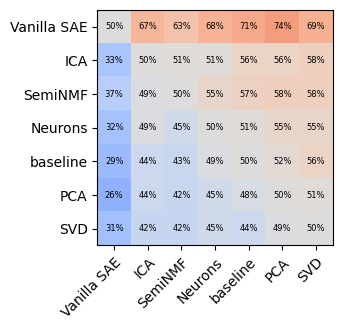

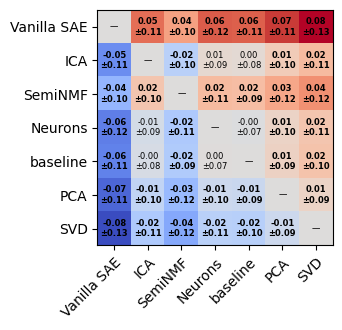

In [2]:
old_df = filter_keep(
    df,
    keep={
        "specification": ["old_consim"],
        "dataset": ["BIOS", "RT", "IMDB", "E"]
    },
    filters={
        "method": ["ClassesAs"],
        "interpretation": ["llm"],
    }
)
old_df = old_df.droplevel("interpretation")

old_df = merge_concept_baseline(old_df)

fig_pct, fig_diff, percentage_matrix, difference_matrix = plot_pairwise_comparison_matrices(
    old_df,
    compared_index="method",
)
fig_pct.savefig(EXPORT_DIR / "old_pairwise_winrate.pdf", bbox_inches="tight")
fig_diff.savefig(EXPORT_DIR / "old_pairwise_difference.pdf", bbox_inches="tight")
plt.show()

## 2. Compare old and new ConSim

Number of keys: Old: 8,200, New: 8,200, Difference: 8,200


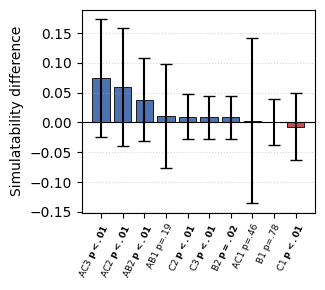

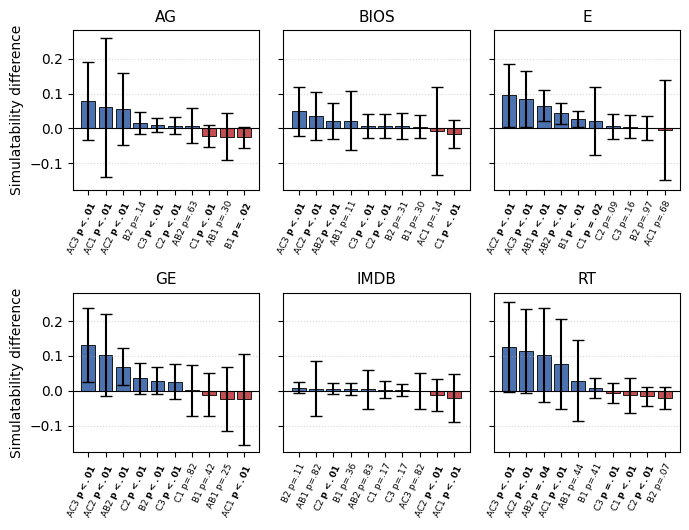

In [3]:
old_df = filter_keep(df, keep={"specification": ["old_consim"]}, drop_single_level=True)
new_df = filter_keep(df, keep={"specification": ["new_consim"]}, drop_single_level=True)

# new - old
differences = score_diff(old_df, new_df)
print(f"Number of keys: Old: {len(old_df):,}, New: {len(new_df):,}, Difference: {len(differences):,}")

fig, _ = plot_difference_bars(
    differences,
    comparison_col="prompt_type",
    ylabel="Simulatability difference",
)
fig_panel, _ = panel_difference_bars(
    differences,
    panel_col="dataset",
    comparison_col="prompt_type",
    ylabel="Simulatability difference",
)
fig.savefig(EXPORT_DIR / "new_old_diff.pdf", bbox_inches="tight")
fig_panel.savefig(EXPORT_DIR / "new_old_diff_datasets.pdf", bbox_inches="tight")
plt.show()

## 3. Check if the new ConSim gives similar conclusions to the old ConSim

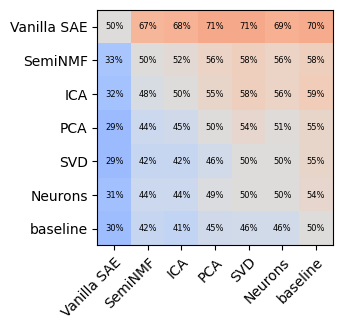

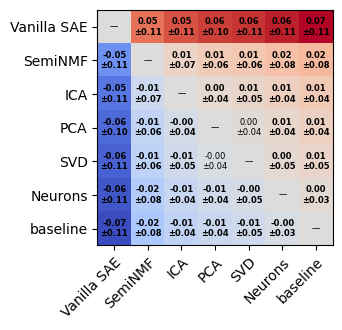

In [4]:
new_df = filter_keep(
    df,
    keep={
        "specification": ["new_consim"],
    },
    filters={
        "method": ["ClassesAs"],
        "interpretation": ["llm"],
    }
)
new_df = new_df.droplevel("interpretation")

new_df = merge_concept_baseline(new_df)

# print_df_keys(new_df)

fig_pct, fig_diff, percentage_matrix, difference_matrix = plot_pairwise_comparison_matrices(
    new_df,
    compared_index="method",
)
fig_pct.savefig(EXPORT_DIR / "new_pairwise_winrate.pdf", bbox_inches="tight")
fig_diff.savefig(EXPORT_DIR / "new_pairwise_difference.pdf", bbox_inches="tight")
plt.show()

## 4. Check topk vs llm interpretations

Number of keys: TopK: 3,600, LLM: 3,600, Difference: 3,600


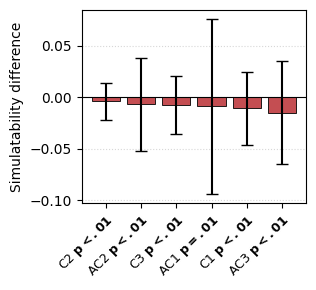

In [5]:
topk_df = filter_keep(df, keep={"interpretation": ["topk"], "specification": ["new_consim"]}, drop_single_level=True)
llm_df = filter_keep(df, keep={"interpretation": ["llm"], "specification": ["new_consim"]}, drop_single_level=True)

# topk - llm
differences = score_diff(topk_df, llm_df)
print(f"Number of keys: TopK: {len(topk_df):,}, LLM: {len(llm_df):,}, Difference: {len(differences):,}")

fig, _ = plot_difference_bars(
    differences,
    comparison_col="prompt_type",
    ylabel="Simulatability difference",
)
fig.savefig(EXPORT_DIR / "llm_topk_diff.pdf", bbox_inches="tight")
# fig_panel, _ = panel_difference_bars(
#     differences,
#     panel_col="dataset",
#     comparison_col="prompt_type",
#     ylabel=f"TopK - LLM",
# )
# fig_panel.savefig(EXPORT_DIR / "llm_topk_diff_datasets.pdf")
plt.show()

## 5. Check the consim_simulator against the new consim prompt writing.

Number of keys: Sim: 4,600, New: 4,600, Difference: 4,600


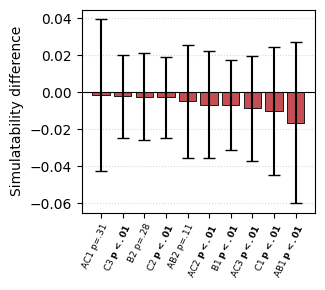

In [6]:
new_df = filter_keep(df, keep={"specification": ["new_consim"]}, filters={"interpretation": ["llm"]}, drop_single_level=True)
sim_df = filter_keep(df, keep={"specification": ["simulator_consim"]}, filters={"interpretation": ["llm"]}, drop_single_level=True)

# sim - new
differences = score_diff(new_df, sim_df)
print(f"Number of keys: Sim: {len(sim_df):,}, New: {len(new_df):,}, Difference: {len(differences):,}")

fig, _ = plot_difference_bars(
    differences,
    comparison_col="prompt_type",
    ylabel="Simulatability difference",
)
fig.savefig(EXPORT_DIR / "sim_new_diff.pdf", bbox_inches="tight")
# fig_panel, _ = panel_difference_bars(
#     differences,
#     panel_col="dataset",
#     comparison_col="prompt_type",
#     ylabel=f"Sim - New",
# )
# fig_panel.savefig(EXPORT_DIR / "sim_new_diff_datasets.pdf")
plt.show()

## 6. Pairwise differences for new ConSim topk

Compare methods separately for non-anonymized (`C*`) and anonymized (`AC*`) prompt types. `ClassesAs` is included by filtering out only the `llm` interpretation instead of keeping only `topk`.

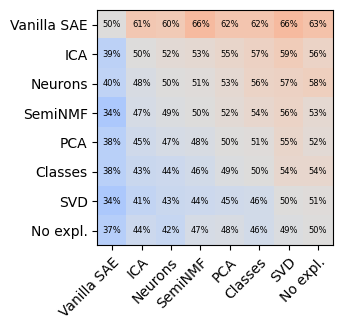

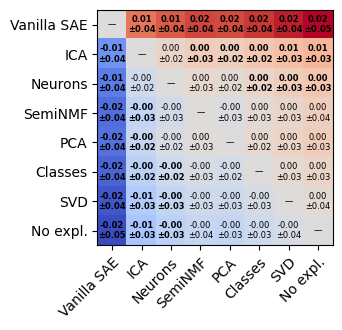

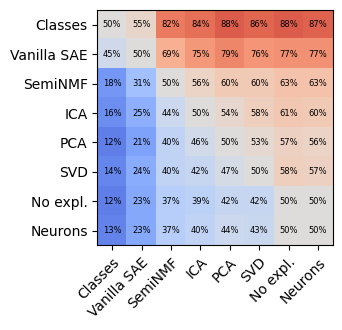

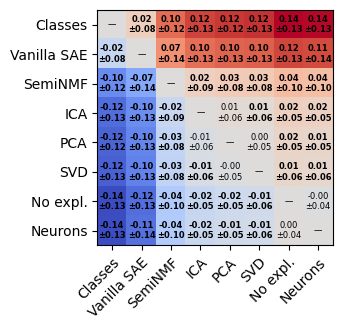

In [7]:
new_topk_df = filter_keep(
    df,
    keep={"specification": ["new_consim"]},
    filters={"interpretation": ["llm"]},
    drop_single_level=True,
)
new_topk_df = new_topk_df.droplevel("interpretation")
new_topk_df = new_topk_df.rename(index={"baseline": "NoExplanation"}, level="method")
new_topk_df = merge_concept_baseline(new_topk_df)

new_topk_non_anon = filter_keep(new_topk_df, keep={"prompt_type": ["C1", "C2", "C3"]})
new_topk_anon = filter_keep(new_topk_df, keep={"prompt_type": ["AC1", "AC2", "AC3"]})

fig_pct, fig_diff, percentage_matrix, difference_matrix = plot_pairwise_comparison_matrices(
    new_topk_non_anon,
    compared_index="method",
)
fig_pct.savefig(EXPORT_DIR / "new_topk_non_anon_pairwise_winrate.pdf", bbox_inches="tight")
fig_diff.savefig(EXPORT_DIR / "new_topk_non_anon_pairwise_difference.pdf", bbox_inches="tight")

fig_pct, fig_diff, percentage_matrix, difference_matrix = plot_pairwise_comparison_matrices(
    new_topk_anon,
    compared_index="method",
)
fig_pct.savefig(EXPORT_DIR / "new_topk_anon_pairwise_winrate.pdf", bbox_inches="tight")
fig_diff.savefig(EXPORT_DIR / "new_topk_anon_pairwise_difference.pdf", bbox_inches="tight")
plt.show()

## 7. Violin plot for anonymized new ConSim topk

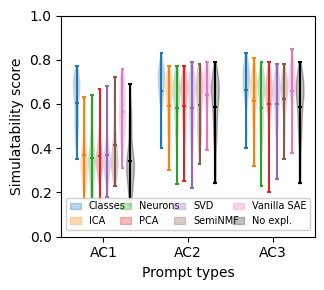

In [8]:
fig, _ = plot_accuracies_violins(new_topk_anon, figsize=(7, 3.2), font_size=18, legend_font_size=13)
fig.savefig(EXPORT_DIR / "new_topk_anon_violins.pdf", bbox_inches="tight")
plt.show()

## 8. Violin plot old and new ConSim topk

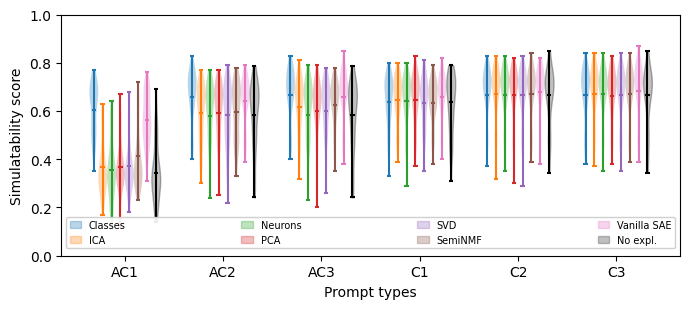

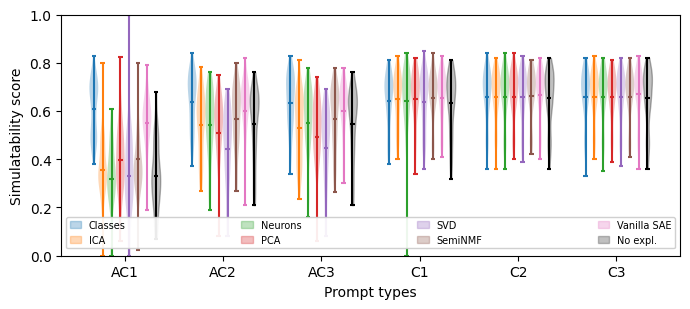

In [9]:
new_topk_df = filter_keep(
    df,
    keep={"specification": ["new_consim"]},
    filters={"interpretation": ["llm"]},
    drop_single_level=True,
)
new_topk_df = new_topk_df.droplevel("interpretation")
new_topk_df = merge_concept_baseline(new_topk_df)
new_topk_df = new_topk_df.rename(index={"baseline": "NoExplanation"}, level="method")

fig, _ = plot_accuracies_violins(new_topk_df, figsize=(7, 3.2))
fig.savefig(EXPORT_DIR / "new_topk_violins.pdf", bbox_inches="tight")
plt.show()

old_topk_df = filter_keep(
    df,
    keep={"specification": ["old_consim"]},
    filters={"interpretation": ["llm"]},
    drop_single_level=True,
)
old_topk_df = old_topk_df.droplevel("interpretation")
old_topk_df = merge_concept_baseline(old_topk_df)
old_topk_df = old_topk_df.rename(index={"baseline": "NoExplanation"}, level="method")

fig, _ = plot_accuracies_violins(old_topk_df, figsize=(7, 3.2))
fig.savefig(EXPORT_DIR / "old_topk_violins.pdf", bbox_inches="tight")
plt.show()